In [1]:
# Plot light curve and phase diagram

import matplotlib.pyplot as plt
import numpy as np
from astropy.timeseries import LombScargle
# from scipy import stats
# from scipy.stats import distributions
# import similaritymeasures

In [2]:
#Choose data path

path = '/media/fernando/KINGSTON/Doutorado/2025/reduced/'
date = '20250706'
object = 'V2400Oph'
channel = '1'
source = '6'

data = f'{path}{date}/export_txt'

In [3]:
#   Reading polarimetry data

data1 = np.loadtxt(f'{data}/{object}_ch{channel}_SRC{source}_polar.txt',skiprows=1)

t1=data1[:,0]
mag1=data1[:,8]
mag1_error=data1[:,9]

In [4]:
# Removendo a media dos dados

mag_mean1=np.mean(mag1)
mag_c1=mag1-mag_mean1
#mag_c1=mag1

In [5]:
#data1 = np.loadtxt('11bocet_pol.txt',skiprows=0)

#t2=data1[:,0]
#mag2=data1[:,1]
#mag2_error=data1[:,2]

In [6]:
# Removendo a media dos dados
#
#mag_mean2=np.mean(mag2)
#mag_c2=mag2-mag_mean2
#mag_c2=mag2

In [7]:
#data1 = np.loadtxt('12bocet_pol.txt',skiprows=0)

#t3=data1[:,0]
#mag3=data1[:,1]
#mag3_error=data1[:,2]

In [8]:
# Removendo a media dos dados

#mag_mean3=np.mean(mag3)
#mag_c3=mag3-mag_mean3
#mag_c3=mag3

In [9]:
#data1 = np.loadtxt('19bocet_pol.txt',skiprows=0)

#t4=data1[:,0]
#mag4=data1[:,1]
#mag4_error=data1[:,2]

In [10]:
# Removendo a media dos dados
#
#mag_mean4=np.mean(mag4)
#mag_c4=mag4-mag_mean4
#mag_c4=mag4

In [11]:
time=t1
mag_c=mag_c1
mag_error=mag1_error
#time=np.concatenate((t1,t2,t3,t4))
#mag_c=np.concatenate((mag_c1,mag_c2,mag_c3,mag_c4))
#mag_error=np.concatenate((mag1_error,mag2_error,mag3_error,mag4_error))
# time=1.*t1
# mag_c=1.*mag_c1
# mag_error=1.*mag1_error

In [12]:
#  Filter data
#
filter="no"
# filter="yes"

In [13]:
##### Lomb Scargle
#
# limites em minutos
p1=5.
p2=200.
# 
p1=p1/60./24.0
p2=p2/60./24.0
# 
# limites em dias
# p1=0.
# p2=1.
#
#
# Numero de frequencias
#
n_freq=int(1e6)
frequency = np.linspace(1./p2, 1./p1, n_freq)

In [14]:
#  Fazendo o Lomb-Scargle
#
#ls = LombScargle(time, mag_c)
ls = LombScargle(time, mag_c,mag_error)
power = ls.power(frequency)
probabilities = [0.001]
fap=ls.false_alarm_level(probabilities) 
#
best_frequency = frequency[np.argmax(power)]
best_period=1./best_frequency
print(' ')
print('Best period in days  ', best_period)
print('Best period in hours  ', best_period*24.)
print('Best period in minutes  ', best_period*24.*60.)
print('False alarm probability of 0.001  ',fap)
print(' ')

 
Best period in days   0.010754709573767719
Best period in hours   0.2581130297704253
Best period in minutes   15.486781786225517
False alarm probability of 0.001   [0.05396319]
 


In [15]:
best_period*60*24

np.float64(15.486781786225514)

In [16]:
927/60

15.45

In [17]:
((927.66/60)/60)/24

0.010736805555555555

In [18]:
#best_period=((927.66/60)/60)/24

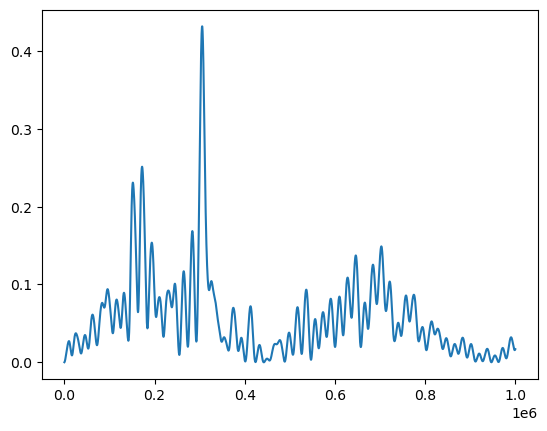

In [19]:
plt.plot(power)

In [20]:
# Calculando phase diagram
#
to=2460863.42808605
phase=((time-to)%best_period)/best_period

In [21]:
phase

array([1.38895857e-01, 1.74034078e-01, 2.09120038e-01, 2.44252890e-01,
       2.79364699e-01, 3.14385582e-01, 3.49439804e-01, 3.84597423e-01,
       4.19716247e-01, 4.55061045e-01, 4.90210567e-01, 5.25267474e-01,
       5.60401365e-01, 5.95471781e-01, 6.30661657e-01, 6.65737399e-01,
       7.01014997e-01, 7.36080521e-01, 7.71144485e-01, 8.06364497e-01,
       8.41468209e-01, 8.76560188e-01, 9.11653639e-01, 9.46657895e-01,
       9.81787456e-01, 1.70483418e-02, 5.22672279e-02, 8.72951682e-02,
       1.22349953e-01, 1.57429505e-01, 1.92496674e-01, 2.27705298e-01,
       2.62942500e-01, 2.98135060e-01, 3.33150531e-01, 3.68248398e-01,
       4.03329595e-01, 4.38395681e-01, 4.73532777e-01, 5.08627916e-01,
       5.43745181e-01, 5.78959217e-01, 6.14079080e-01, 6.49145166e-01,
       6.84219349e-01, 7.19291887e-01, 7.54486006e-01, 7.89605436e-01,
       8.24760284e-01, 8.59839836e-01, 8.95039844e-01, 9.30116711e-01,
       9.65250646e-01, 3.87697962e-04, 3.54506666e-02, 7.05441173e-02,
      

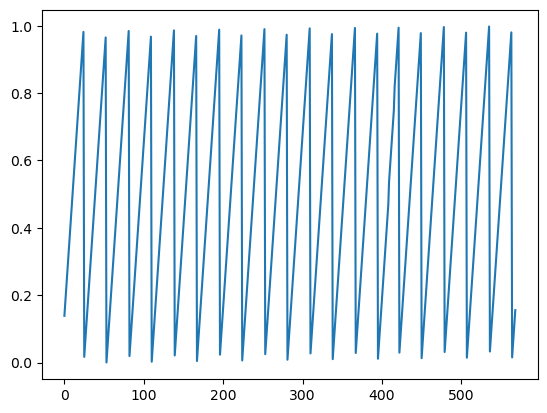

In [22]:
plt.plot(phase)

In [23]:
# Binning data in the best period
#
number_bins=6
center_bin=np.zeros(number_bins)
bin_means=np.zeros(number_bins)
bin_size=1./number_bins
bins = np.linspace(0, 1, number_bins+1)
digitized = np.digitize(phase, bins)
# print(bins)
# print(digitized)

In [24]:
number_bins

6

In [25]:
center_bin

array([0., 0., 0., 0., 0., 0.])

In [26]:
bin_means

array([0., 0., 0., 0., 0., 0.])

In [27]:
bin_size

0.16666666666666666

In [28]:
bins

array([0.        , 0.16666667, 0.33333333, 0.5       , 0.66666667,
       0.83333333, 1.        ])

In [29]:
digitized

array([1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5, 5, 5, 5, 6, 6,
       6, 6, 6, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 4, 4, 4, 4, 4,
       5, 5, 5, 5, 5, 6, 6, 6, 6, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3,
       3, 3, 4, 4, 4, 4, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 1, 1, 1, 1, 1, 2,
       2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 6, 6, 6, 6,
       1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5,
       5, 5, 6, 6, 6, 6, 6, 1, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4,
       4, 4, 4, 4, 5, 5, 5, 5, 5, 6, 6, 6, 6, 1, 1, 1, 1, 1, 2, 2, 2, 2,
       2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 1, 1,
       1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5,
       6, 6, 6, 6, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4,
       4, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 1, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3,
       3, 3, 3, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 6, 6, 6, 6, 1, 1, 1, 1, 1,
       2, 2, 2, 2, 2, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5,

In [30]:
for i in range(1, len(bins)):
    im=i-1
    center_bin[im]=bins[i]-0.5*bin_size
    bin_means[im]=np.mean(mag_c[digitized == i])
    print(i,center_bin[im],bin_means[im]) 
#
#    Model sinuosoidal
# 
y_fit = ls.model(time, best_frequency)

1 0.08333333333333333 -0.0025581370807264223
2 0.25 -0.0009880002088514222
3 0.4166666666666667 0.0012964486327487548
4 0.5833333333333333 0.002731981977519191
5 0.7499999999999999 0.0014907934698112119
6 0.9166666666666666 -0.0018907270761650183


In [31]:
mag_c

array([ 1.44385886e-04, -1.31202551e-03,  4.75054859e-05,  1.41695279e-03,
        1.12722219e-03,  3.63270039e-03,  5.25052509e-03,  5.66706069e-03,
        5.59026349e-03,  4.07712719e-03,  2.63907879e-03,  1.08311269e-03,
        9.59280486e-04, -1.67924614e-04, -2.49543511e-03, -3.94785791e-03,
       -3.73408741e-03, -2.86445911e-03, -2.39894891e-03, -3.75840561e-03,
       -3.15084381e-03, -4.09997281e-03, -3.98674181e-03, -3.74151701e-03,
       -3.83649531e-03, -4.73994261e-03, -4.84999321e-03, -3.07571251e-03,
       -3.43404181e-03, -2.17589661e-03, -1.81353581e-03, -1.07593321e-03,
       -9.38980114e-04,  2.05003286e-04,  8.54767786e-04,  3.96905086e-04,
        7.76253286e-04,  3.57322886e-04,  1.40487779e-03,  3.58456069e-03,
        3.25773829e-03,  3.11302429e-03,  3.57059249e-03,  5.62774739e-03,
        5.36673939e-03,  6.67475349e-03,  4.00114509e-03,  3.23594639e-03,
        2.78184609e-03,  3.24511729e-03, -6.64443141e-05, -1.98749171e-03,
       -1.86639931e-03, -

In [32]:
len(mag_c)

569

In [33]:
mag_c[digitized==1]

array([ 0.00014439, -0.00473994, -0.00484999, -0.00307571, -0.00343404,
       -0.0021759 , -0.00382195, -0.00314094, -0.00303175, -0.00274923,
       -0.00406732, -0.00676998, -0.00741629, -0.00727212, -0.00621592,
       -0.0047666 , -0.00537578, -0.00524815, -0.00607191, -0.00564877,
       -0.00866232, -0.00562235, -0.0060882 , -0.00689618, -0.00551943,
       -0.00376687, -0.00290377, -0.00342388, -0.0027811 , -0.00194839,
       -0.00149644, -0.00212874, -0.00067851, -0.00062375, -0.00104038,
       -0.00120907,  0.00129095, -0.00136293, -0.00041035, -0.00263358,
       -0.00235836, -0.00915159, -0.00790465, -0.00734273, -0.00731262,
       -0.00830032, -0.00333002, -0.00211793, -0.00113348, -0.00110212,
       -0.00083433,  0.00052287,  0.00119237,  0.00135928,  0.00115294,
        0.00347489,  0.00290129,  0.00280839, -0.00042947, -0.00107254,
        0.00321623,  0.00343841,  0.00472741,  0.00507001, -0.00821001,
       -0.00850262, -0.0076876 , -0.00647176, -0.00553169, -0.00

In [34]:
bin_means

array([-0.00255814, -0.000988  ,  0.00129645,  0.00273198,  0.00149079,
       -0.00189073])

In [35]:
y_fit

array([-3.09507128e-03, -2.55265734e-03, -1.88176688e-03, -1.11310188e-03,
       -2.85287536e-04,  5.59798173e-04,  1.38424697e-03,  2.14954820e-03,
        2.81535505e-03,  3.35322481e-03,  3.73048000e-03,  3.93186774e-03,
        3.94869921e-03,  3.77998742e-03,  3.43262645e-03,  2.92567479e-03,
        2.27877599e-03,  1.53082522e-03,  7.14515021e-04, -1.34490358e-04,
       -9.68576918e-04, -1.74986156e-03, -2.44082660e-03, -3.00671755e-03,
       -3.42334874e-03, -3.66881422e-03, -3.72929784e-03, -3.60343593e-03,
       -3.29783302e-03, -2.82689499e-03, -2.21379961e-03, -1.48494346e-03,
       -6.77376302e-04,  1.67846926e-04,  1.00638508e-03,  1.80379234e-03,
        2.51914151e-03,  3.11797922e-03,  3.57243760e-03,  3.85887787e-03,
        3.96407151e-03,  3.88220153e-03,  3.61766008e-03,  3.18409281e-03,
        2.60204427e-03,  1.89978543e-03,  1.10841607e-03,  2.70525218e-04,
       -5.75697269e-04, -1.38662912e-03, -2.12722015e-03, -2.75654458e-03,
       -3.24756939e-03, -

In [36]:
len(y_fit)

569

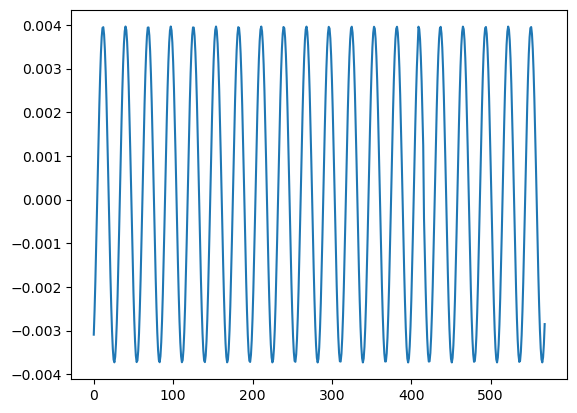

In [37]:
plt.plot(y_fit)

In [38]:
# Filtrando
#
if (filter != "no"):
	f= open("bocet_fot_p1_509.txt","x")
	mag_filtered=np.zeros(len(mag_c))
	for i in range(0, len(mag_c)):
#
#    Aqui eu filtro por media do bin - nao eh bom
#
# 		mag_filtered[i]=mag[i]-bin_means[digitized[i]-1]
#  
#    Aqui filtro por Model sinuosoidal
# 
		mag_filtered[i]=mag_c[i]-y_fit[i]
		f.write(f"{time[i]} {mag_c[i]} {mag_filtered[i]} \n")
	
#
	f.close()

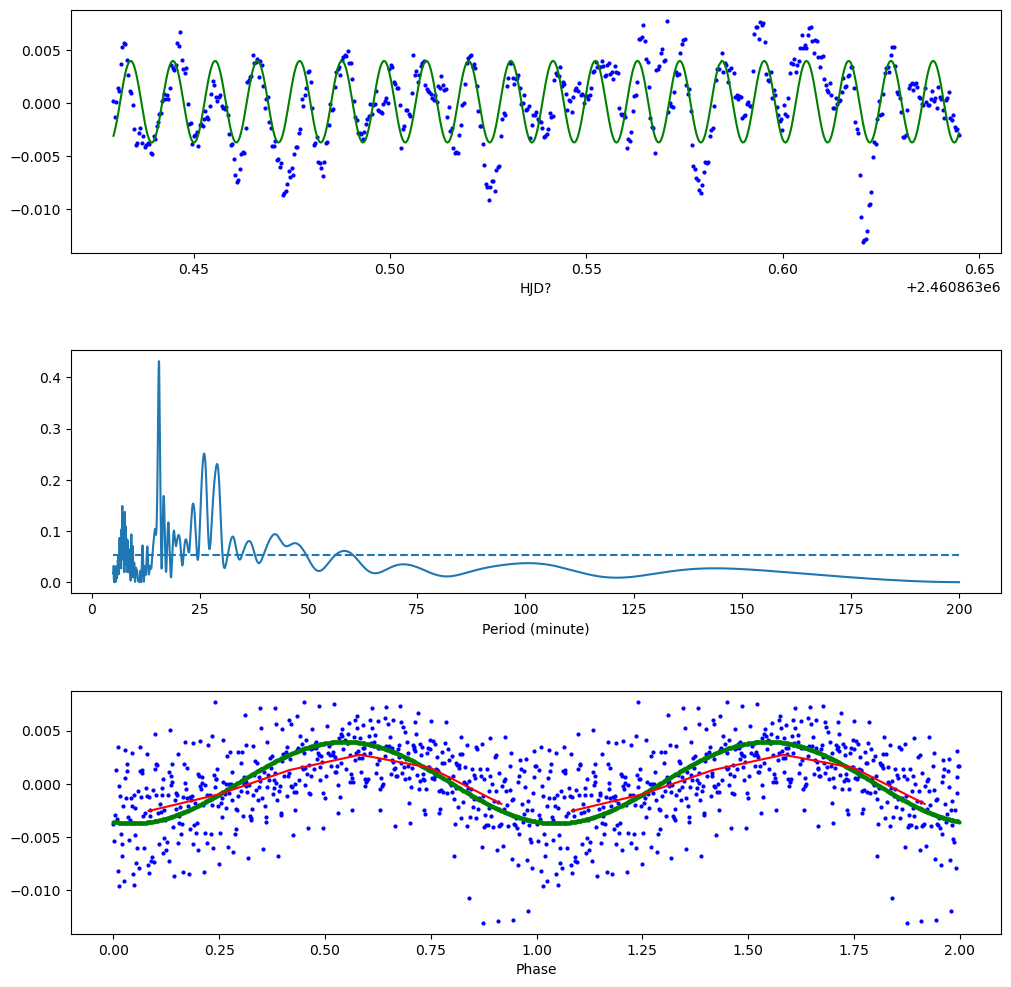

In [39]:
#### Plot

plt.close('all')

#f, ax = plt.subplots(2, sharex=True)
f, ax = plt.subplots(3, figsize=(12, 12), sharex=False)
f.subplots_adjust(hspace=0.4)
#f.align_ylabels(ax[0:1])

ax[0].plot(time,mag_c,'b.',markersize=4)
ax[0].plot(time,y_fit,'g-',markersize=4)
ax[0].set_xlabel('HJD?')
# ax[0].set_xlim(52455.2,52455.4)

ax[1].plot(1./frequency*24.*60.,power)
ax[1].set_xlabel('Period (minute)')
xmin=p1*24.*60.
xmax=p2*24.*60.
# ax[1].plot(1./frequency,power)
# ax[1].set_xlabel('Period (d)')
# xmin=p1
# xmax=p2
ax[1].hlines(fap,xmin,xmax,linestyles='dashed')

ax[2].plot(phase,mag_c,'b.',markersize=4)
ax[2].plot(phase+1.0,mag_c,'b.',markersize=4)
ax[2].plot(phase,y_fit,'g.',markersize=4)
ax[2].plot(phase+1.0,y_fit,'g.',markersize=4)
ax[2].plot(center_bin,bin_means,'r-',markersize=4)
ax[2].plot(center_bin+1.0,bin_means,'r-',markersize=4)
ax[2].set_xlabel('Phase')
# ax[2].set_xlim(0,2)
#ax[2].plot(t_fit,y_fit,'k-')

# print(time.size)
# print(time_b.size)
# print(time_v.size)
plt.show()